## Attempt to map between global and local lens maps

Firstly, we set up teh julia environment and necessary packages.

In [1]:
import Pkg: activate
activate(joinpath(pwd(), ".."))
using Optical_Drift_Effects

  Activating project at `~/Documents/Optical_Drift_Effects`


In [2]:
using LinearAlgebra
using StaticArrays
using Plots

# Lens set-up

In [3]:
θE = 1.0
q = 0.5
φ=0.0

lens = SIE(θE, q, φ )

SIE(1.0, 0.5, 0.0, 0.0, 0.0, 1.0e-6, 1.0e-12)

# Source set-up

In [4]:
β0 = SVector{2,Float64}(-1.0, 0.4) # Source position in the source plane (βx, βy)
Rs = 0.005 # Effective radius of the Sersic profile

src = SersicSource(
    I0=1.0,
    Re=Rs,
    n=2.0, # Sersic index (n=1 exponential, n=4 de Vaucouleurs)
    q=1.0, #axis ratio (1.0 = circular)
    ϕ=0.0, # position angle (radians, for elliptical sources)
    β0=β0,
    normalize=:none 
)

SersicSource(1.0, 0.005, 2.0, 1.0, 0.0, [-1.0, 0.4], 1.0e-12, :none, 1.0)

# Grid set-up

In [5]:
os = 50          # oversampling factor (pixels per output pixel, per axis)

Nx_pix, Ny_pix = 50, 50                 # desired output (pixelated) resolution
Nx_hi,  Ny_hi  = os * Nx_pix, os * Ny_pix  # high-res ray grid

xmin, xmax = -4.2, 4.2
ymin, ymax = -4.2, 4.2

# High-res ray grid 
xs_hi = range(xmin, xmax; length=Nx_hi)
ys_hi = range(ymin, ymax; length=Ny_hi)

# Output pixel centres (for plot axes)
xs_pix = range(xmin, xmax; length=Nx_pix)
ys_pix = range(ymin, ymax; length=Ny_pix)


-4.2:0.17142857142857143:4.2

# Critical and Caustic Curves

In [6]:
critical_polylines = critical_curves(lens, xs_hi, ys_hi)
caustic_polylines = caustic_curves(lens, critical_polylines)

1-element Vector{Vector{SVector{2, Float64}}}:
 [[0.7809803799541932, -0.6837518081901414], [0.7815070031293454, -0.6834344982340682], [0.7841498510700952, -0.681843900207441], [0.7867938255272688, -0.6802556458673573], [0.7894389253323414, -0.6786697285766892], [0.7920851492849302, -0.6770861417723137], [0.7947324961532443, -0.6755048789641463], [0.7973809646745269, -0.6739259337341887], [0.8000305535554993, -0.6723492997355831], [0.8026812614727956, -0.6707749706916827]  …  [0.7592294540360677, -0.6969638317665786], [0.7604146161964538, -0.6962385358503591], [0.7630471097597681, -0.6946297476960702], [0.7656807556014809, -0.6930233453204057], [0.7683155526801126, -0.6914193216162902], [0.7709514999195578, -0.6898176695574014], [0.7735885962095561, -0.6882183821971146], [0.7762268404061627, -0.686621452667456], [0.7788662313322118, -0.6850268741780715], [0.7809803799541932, -0.6837518081901414]]

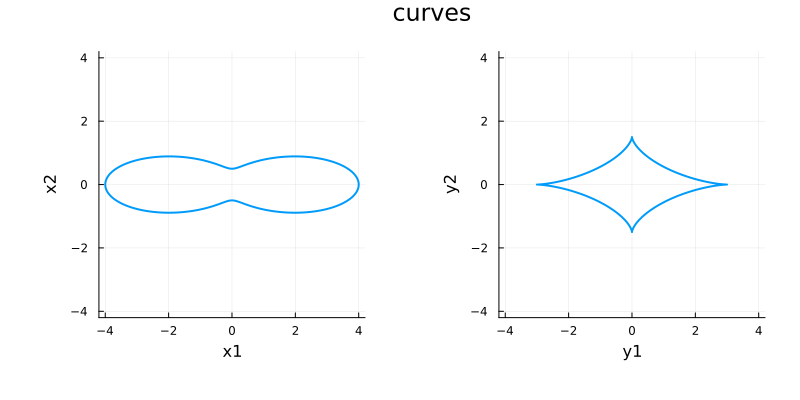

In [7]:
p_src = plot(; aspect_ratio=:equal,
    xlims=(xmin, xmax), ylims=(ymin, ymax),
    xlabel="y1", ylabel="y2",
    legend=false
)

p_lens = plot(; aspect_ratio=:equal,
    xlims=(xmin, xmax), ylims=(ymin, ymax),
    xlabel="x1", ylabel="x2",
    legend=false
)

for poly in caustic_polylines
    plot!(p_src, first.(poly), last.(poly); lw=2)
end

for poly in critical_polylines
    plot!(p_lens, first.(poly), last.(poly); lw=2)
end

whole_plot = plot(p_lens, p_src; layout=(1,2), plot_title="curves", size=(800, 400), left_margin=12Plots.mm, right_margin=6Plots.mm,
    top_margin=6Plots.mm,   bottom_margin=12Plots.mm)

whole_plot

# Coordinate mapping

In [8]:
# -----------------------------------------------------------------------
# Fold / Cusp classification of caustic/critical curves
#
# At a critical point x_c where det(A) = 0, the caustic velocity is
#   dy/dt = A(x_c) * dx/dt
# Let v = null eigenvector of A, and t = tangent to the critical curve.
#
#   Fold: t NOT parallel to v  -->  dy/dt != 0
#   Cusp: t     parallel to v  -->  dy/dt  = 0
#
# Key insight: the null eigenvector of A in the global frame is exactly the
# second row of M (the degenerate local-frame axis mapped back to global).
# This avoids needing eigen() and sidesteps sign-convention issues in
# deflection_jacobian.
# -----------------------------------------------------------------------

all_labels = [classify_caustic_polyline(poly, lens) for poly in critical_polylines]

for (k, labels) in enumerate(all_labels)
    println("Polyline ", k, ": ", count(==(:fold), labels), " fold, ",
            count(==(:cusp), labels), " cusp")
end



Polyline 1: 6193 fold, 84 cusp


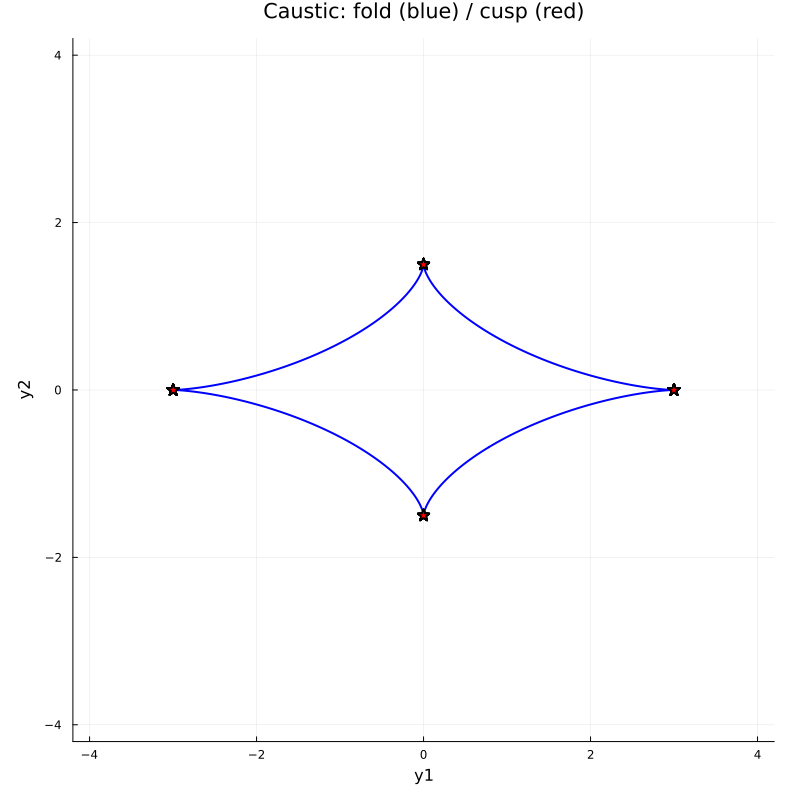

In [9]:
# Plot the caustic coloured by type: fold = blue, cusp = red
p_class = plot(; aspect_ratio=:equal, xlims=(xmin,xmax), ylims=(ymin,ymax),
               xlabel="y1", ylabel="y2", title="Caustic: fold (blue) / cusp (red)",
               size=(800,800), legend=false)

for (k, (crit_poly, caust_poly)) in enumerate(zip(critical_polylines, caustic_polylines))
    labels = all_labels[k]
    i_fold = findall(==(:fold), labels)
    if !isempty(i_fold)
        runs = UnitRange{Int}[]
        start = i_fold[1]
        for j in 2:length(i_fold)
            if i_fold[j] != i_fold[j-1] + 1
                push!(runs, start:i_fold[j-1])
                start = i_fold[j]
            end
        end
        push!(runs, start:i_fold[end])
        for r in runs
            plot!(p_class, first.(caust_poly[r]), last.(caust_poly[r]); lw=2, color=:blue)
        end
    end
    i_cusp = findall(==(:cusp), labels)
    if !isempty(i_cusp)
        scatter!(p_class,
            first.(caust_poly[i_cusp]), last.(caust_poly[i_cusp]);
            color=:red, ms=6, markershape=:star5)
    end
end
p_class


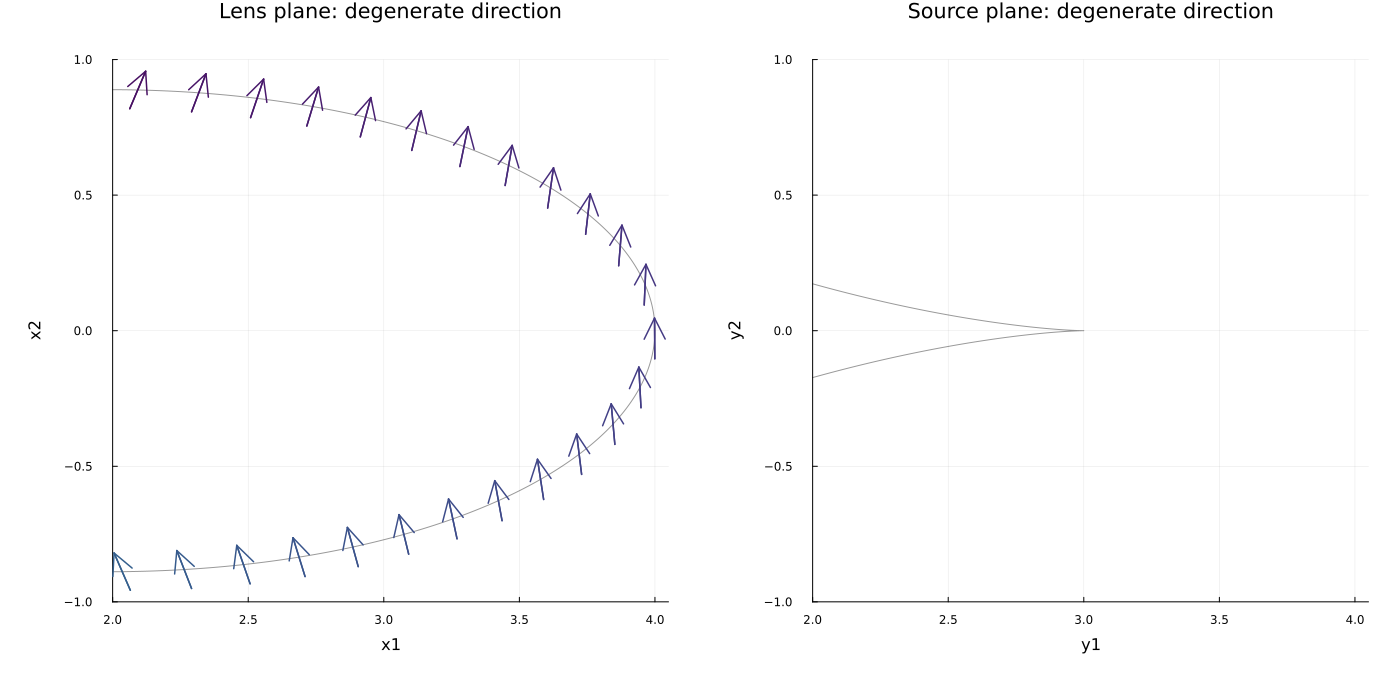

In [19]:
# -----------------------------------------------------------------------
# Visualise the degenerate direction of the Jacobian in both planes.
#
# Note: A*v = 0 by definition (v is the null eigenvector), so the
# degenerate direction cannot be mapped through A in a non-trivial way.
# Instead we draw v at the critical curve point (lens plane) and the
# same vector v at the corresponding caustic point (source plane),
# showing how the merging direction sits in each plane.
#
# Null eigenvector in global frame: v proportional to (-A12, A11)
# -----------------------------------------------------------------------

every      = 70
scale      = 0.15

p_crit  = plot(; aspect_ratio=:equal, xlims=(2,4.05), ylims=(-1,1),
                xlabel="x1", ylabel="x2",
                title="Lens plane: degenerate direction",
                legend=false, size=(700,700))

p_caust = plot(; aspect_ratio=:equal, xlims=(2,4.05), ylims=(-1,1),
                xlabel="y1", ylabel="y2",
                title="Source plane: degenerate direction",
                legend=false, size=(700,700))

for (crit_poly, caust_poly) in zip(critical_polylines, caustic_polylines)
    n = length(crit_poly)

    plot!(p_crit,  first.(crit_poly),  last.(crit_poly);  lw=1, color=:black, alpha=0.4)
    plot!(p_caust, first.(caust_poly), last.(caust_poly); lw=1, color=:black, alpha=0.4)

    # Arc-length parameter for colouring
    arc = cumsum([0.0; [norm(SVector(crit_poly[i][1]-crit_poly[i-1][1],
                                    crit_poly[i][2]-crit_poly[i-1][2]))
                        for i in 2:n]])
    arc ./= arc[end]

    for i in 1:every:n
        theta_c = SVector(crit_poly[i][1],  crit_poly[i][2])
        y_c     = SVector(caust_poly[i][1], caust_poly[i][2])
        col     = cgrad(:viridis)[arc[i]]

        # Null eigenvector of A: v proportional to (-A12, A11)
        A = deflection_jacobian(lens, theta_c)
        v = SVector(-A[1,2], A[1,1])
        v = v / norm(v)

        # Draw v centred on the critical curve point (lens plane)
        quiver!(p_crit,
                [theta_c[1] - 0.5scale*v[1]],
                [theta_c[2] - 0.5scale*v[2]],
                quiver=([scale*v[1]], [scale*v[2]]);
                color=col, lw=1.5)

        # Draw the same v centred on the caustic point (source plane)
        # A*v = 0 so v is drawn at the caustic location without transformation
        # quiver!(p_caust,
        #         [y_c[1] - 0.5scale*v[1]],
        #         [y_c[2] - 0.5scale*v[2]],
        #         quiver=([scale*v[1]], [scale*v[2]]);
        #         color=col, lw=1.5)
    end
end

plot(p_crit, p_caust; layout=(1,2), size=(1400,700),
     left_margin=12Plots.mm, right_margin=6Plots.mm,
     top_margin=6Plots.mm,   bottom_margin=12Plots.mm)

In [ ]:
# -----------------------------------------------------------------------
# Fold image positions in normal (local) coordinates
#
# Given a source y_s near a fold point x_c, in local coords:
#   du = M(x_c) * (y_s - y_c)
#
# Fold lens equation:
#   du_2 = -1/2 Psi_222 dtheta_2^2
#   du_1 =  lambda_+ dtheta_1 - 1/2 Psi_122 dtheta_2^2
#
# Inversion:
#   dtheta_2 = +/- sqrt(-2 du_2 / Psi_222)
#   dtheta_1 = (du_1 + 1/2 Psi_122 dtheta_2^2) / lambda_+
# -----------------------------------------------------------------------

function fold_image_positions(y_s::AbstractVector, x_c::AbstractVector, lens::SIE)
    theta_c = SVector(Float64(x_c[1]), Float64(x_c[2]))

    # Caustic point
    y_c = theta_c - deflection(lens, theta_c)

    # Local-frame source offset
    M  = ckn_M(lens, theta_c)
    du = M * (SVector(Float64(y_s[1]), Float64(y_s[2])) - y_c)

    # Non-zero eigenvalue of the magnification matrix at x_c:
    # lambda_+ = trace(A) because the other eigenvalue is 0 at the critical curve.
    # deflection_jacobian diagonal entries are 1 - psi_ii, so trace = A[1,1]+A[2,2].
    A_c        = deflection_jacobian(lens, theta_c)
    lambda_plus = A_c[1,1] + A_c[2,2]   # trace = sum of eigenvalues; one is 0

    # Third-derivative tensor in local frame
    Psi    = fold_Psi(lens, theta_c)
    Psi222 = Psi[2,2,2]
    Psi122 = Psi[1,2,2]

    disc = -2du[2] / Psi222
    disc < 0 && return SVector{2,Float64}[]   # source outside fold

    images = SVector{2,Float64}[]
    for sgn in (+1.0, -1.0)
        dt2   = sgn * sqrt(disc)
        dt1   = (du[1] + 0.5 * Psi122 * dt2^2) / lambda_plus
        x_img = theta_c + M' * SVector(dt1, dt2)
        push!(images, x_img)
    end
    return images
end

# Test: nudge a source just inside the caustic along the null direction
test_crit  = critical_polylines[1][100]
test_caust = caustic_polylines[1][100]

M_test  = ckn_M(lens, SVector(test_crit[1], test_crit[2]))
Psi_test = fold_Psi(lens, SVector(test_crit[1], test_crit[2]))
epsilon = 0.005
# The fold images exist when -du2/Psi222 > 0, i.e. du2 and Psi222 have opposite signs.
# Nudge the source in the direction that satisfies this: -sign(Psi222) in u2.
inside_dir = -sign(Psi_test[2,2,2])
y_test  = test_caust + inside_dir * epsilon * SVector(M_test[2,1], M_test[2,2])

imgs = fold_image_positions(y_test, test_crit, lens)
println("Fold image positions (normal-form approximation):")
for (i, img) in enumerate(imgs)
    println("  image ", i, ": x = ", round.(img; digits=6))
end

Fold image positions (normal-form approximation):
  image 1: x = [1.68184, 0.96346]
  image 2: x = [1.766302, 0.798136]
